In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

glass = pd.read_csv('glass.csv')
glass.head(2)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1


** Take-Home Assignment **

Logistic Regression:

Try different thresholds for computing predictions. By default it is 0.5. Use predict_proba function to compute probabilities and then try custom thresholds and see their impact on Accuracy, Precision and Recall

Do the same analysis for other columns

Fit a Logistic Regression Model on all features. Remember to preprocess data(eg. normalization and one hot encoding)

Plot ROC Curves for each model

Clustering:

Repeat the above exercise for different values of k

How do the inertia and silhouette scores change?

What if you don't scale your features?

Is there a 'right' k? Why or why not?

Repeat the following exercise for food nutrients dataset

In [25]:
X = glass.drop('Type', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
def evaluate_kmeans(X, k_range):
    inertia_scores = []
    silhouette_scores = []
    
    data = X

    # doing the k means 
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)
        inertia_scores.append(kmeans.inertia_)
        
        # Silhouette score is not defined for k=1
        if k > 1:
            sil_score = silhouette_score(data, labels)
            silhouette_scores.append(sil_score)
        else:
            silhouette_scores.append(0) # for the when only 1 cluster, can't compare it to anything
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    ax[0].plot(k_range, inertia_scores, 'o-')
    ax[0].set_xlabel('Number of clusters (k)')
    ax[0].set_ylabel('Inertia')
    ax[0].set_title(f'Elbow Method ')
    
    ax[1].plot(k_range[1:], silhouette_scores[1:], 'o-')  # Skip k=1 for silhouette
    ax[1].set_xlabel('Number of clusters (k)')
    ax[1].set_ylabel('Silhouette Score')
    ax[1].set_title(f'Silhouette Method')
    
    plt.tight_layout()
    plt.show()

    return inertia_scores, silhouette_scores

z-scored


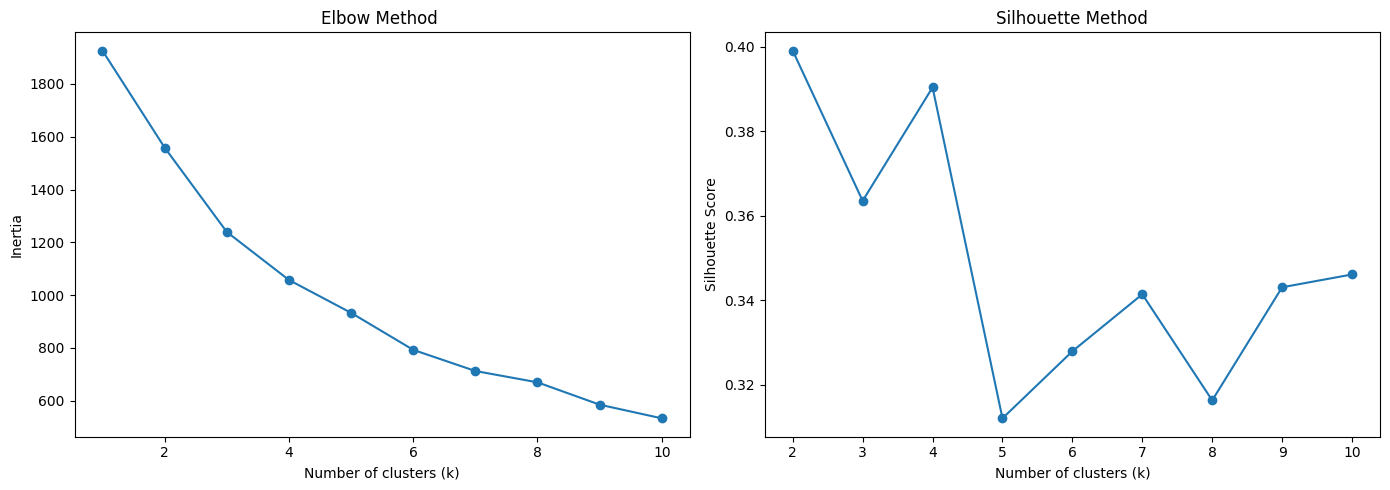

raw


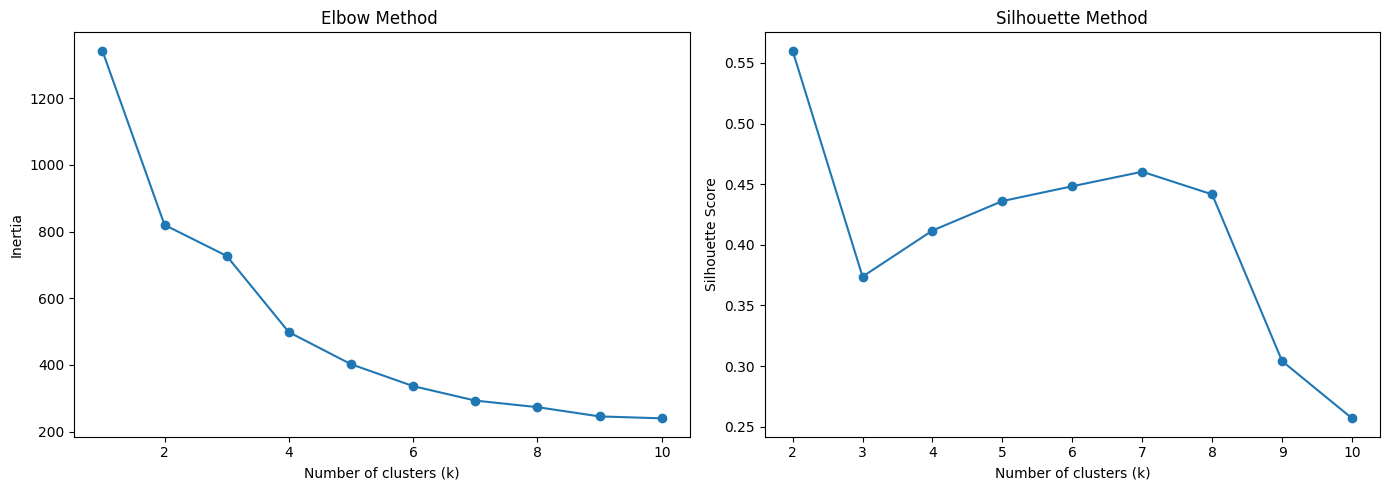

In [27]:
# Evaluate clustering with different k values (scaled)
k_range = range(1, 11)
print("z-scored")
inertia_scaled, silhouette_scaled = evaluate_kmeans(X_scaled, k_range)
print("raw")
# Evaluate clustering with different k values (unscaled)
inertia_unscaled, silhouette_unscaled = evaluate_kmeans(X, k_range)

In [28]:
def visualize_clusters(X, k):
    data = X
    
    # Reduce to 2D for visualization
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(data)
    
    # Fit KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data)
    
    # Plot
    plt.figure(figsize=(10, 7))
    for i in range(k):
        plt.scatter(X_2d[labels == i, 0], X_2d[labels == i, 1], label=f'Cluster {i+1}')
    
    plt.title(f'KMeans Clustering (k={k})')
    plt.legend()
    plt.show()

scaled


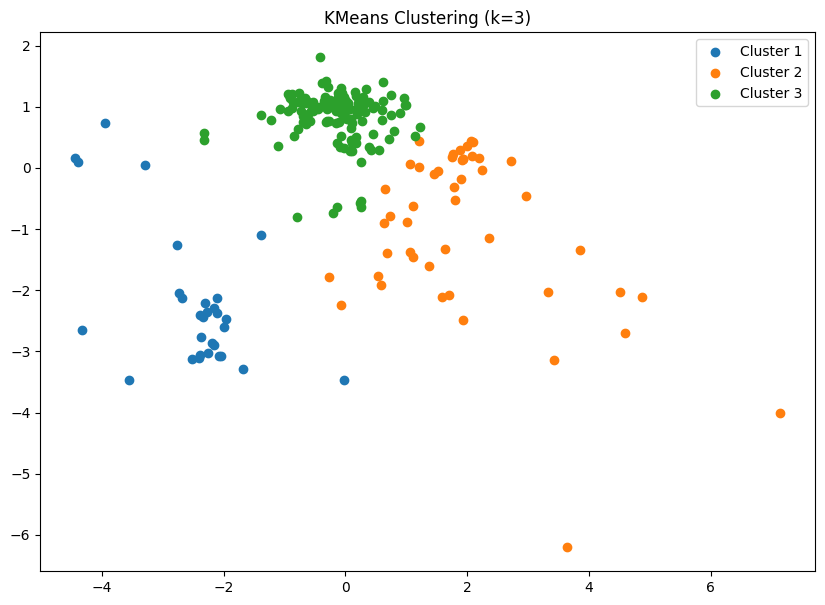

raw


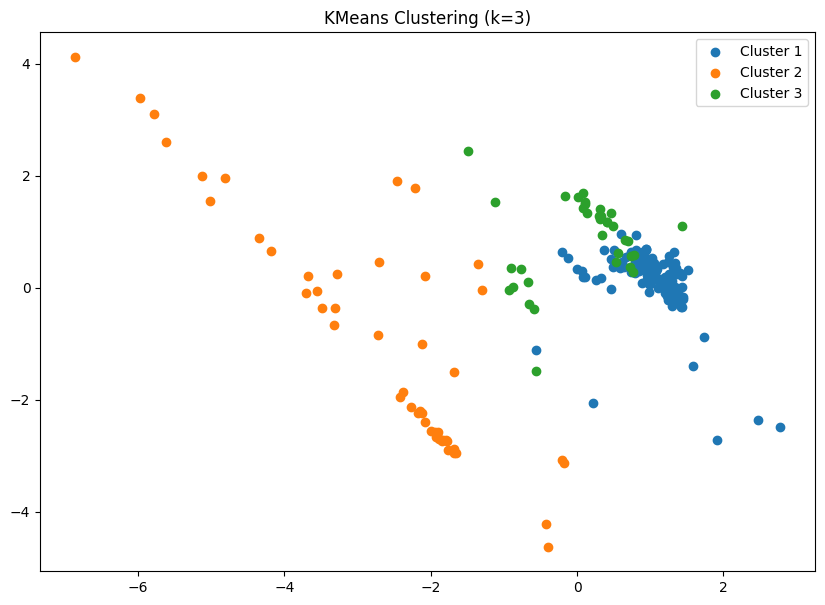

In [29]:
best_k_scaled = 3     
best_k_unscaled = 3
print("scaled")
visualize_clusters(X_scaled, best_k_scaled)
print("raw")
visualize_clusters(X, best_k_unscaled)

# logistic regression

In [31]:
random_state = 42


X = glass.drop('Type', axis=1)
y = glass['Type']


y_binary = (y == 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)

scaler = StandardScaler()


X_train_processed = scaler.fit_transform(X_train)
X_test_processed = scaler.transform(X_test)


In [36]:
# model = LogisticRegression(random_state=42)
# model.fit(X_train_processed, y_train)
# y_prob = model.predict_proba(X_test_processed)[:, 1]

In [51]:
thresholds = np.arange(0.1, 1.0, 0.1)
accuracy_scores = []
precision_scores = []
recall_scores = []


for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)

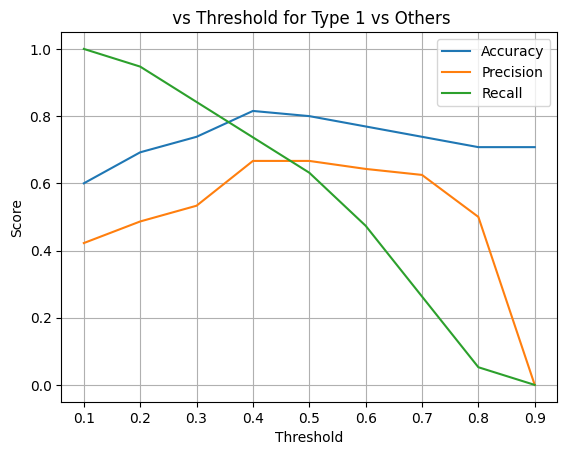

In [41]:
plt.plot(thresholds, accuracy_scores,  label='Accuracy')
plt.plot(thresholds, precision_scores,  label='Precision')
plt.plot(thresholds, recall_scores, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(' vs Threshold for Type 1 vs Others')
plt.legend()
plt.grid(True)

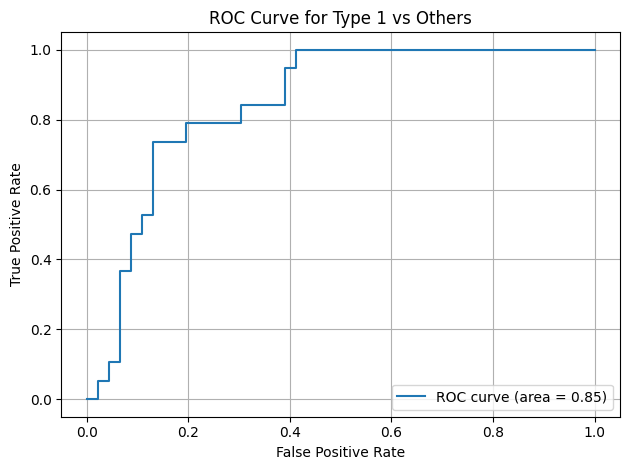

In [48]:

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Type 1 vs Others')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

In [49]:
results = pd.DataFrame({
    'Threshold': thresholds,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores
})
print("Results for different thresholds:")
print(results)

Results for different thresholds:
   Threshold  Accuracy  Precision    Recall
0        0.1  0.600000   0.422222  1.000000
1        0.2  0.692308   0.486486  0.947368
2        0.3  0.738462   0.533333  0.842105
3        0.4  0.815385   0.666667  0.736842
4        0.5  0.800000   0.666667  0.631579
5        0.6  0.769231   0.642857  0.473684
6        0.7  0.738462   0.625000  0.263158
7        0.8  0.707692   0.500000  0.052632
8        0.9  0.707692   0.000000  0.000000
